In [2]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(project_root)

c:\Users\Aditi Mundra\OneDrive\Desktop\Butterfly Classification


In [3]:
from tensorflow.keras.models import load_model

from src.evaluate import (
    get_predictions,
    get_true_labels,
    generate_classification_report,
    generate_confusion_matrix
)

from src.visualization import (
    plot_confusion_matrix
)

In [4]:
model = load_model(
    "../outputs/models/best_model.keras"
)

In [6]:
from src.data_loader import load_leeds_dataset

images, labels = load_leeds_dataset(
    "../data/raw/leedsbutterfly/images"
)

In [7]:
from src.preprocessing import (
    normalize_images,
    encode_labels,
    one_hot_encode,
    create_train_test_split
)

images = normalize_images(images)

encoded_labels, encoder = encode_labels(labels)

categorical_labels = one_hot_encode(
    encoded_labels
)

In [8]:
X_train, X_test, y_train, y_test = (
    create_train_test_split(
        images,
        categorical_labels
    )
)

In [9]:
print(X_test.shape)
print(y_test.shape)

(167, 224, 224, 3)
(167, 10)


In [10]:
y_pred = get_predictions(
    model,
    X_test
)

y_true = get_true_labels(
    y_test
)

6/6 ━━━━━━━━━━━━━━━━━━━━ 35s 5s/step


In [11]:
print(
    generate_classification_report(
        y_true,
        y_pred,
        sorted(set(labels))
    )
)

              precision    recall  f1-score   support

         001       1.00      1.00      1.00        16
         002       1.00      1.00      1.00        19
         003       1.00      1.00      1.00        12
         004       1.00      1.00      1.00        18
         005       1.00      1.00      1.00        18
         006       1.00      1.00      1.00        20
         007       1.00      0.94      0.97        18
         008       1.00      1.00      1.00        11
         009       0.95      1.00      0.97        18
         010       0.94      0.94      0.94        17

    accuracy                           0.99       167
   macro avg       0.99      0.99      0.99       167
weighted avg       0.99      0.99      0.99       167



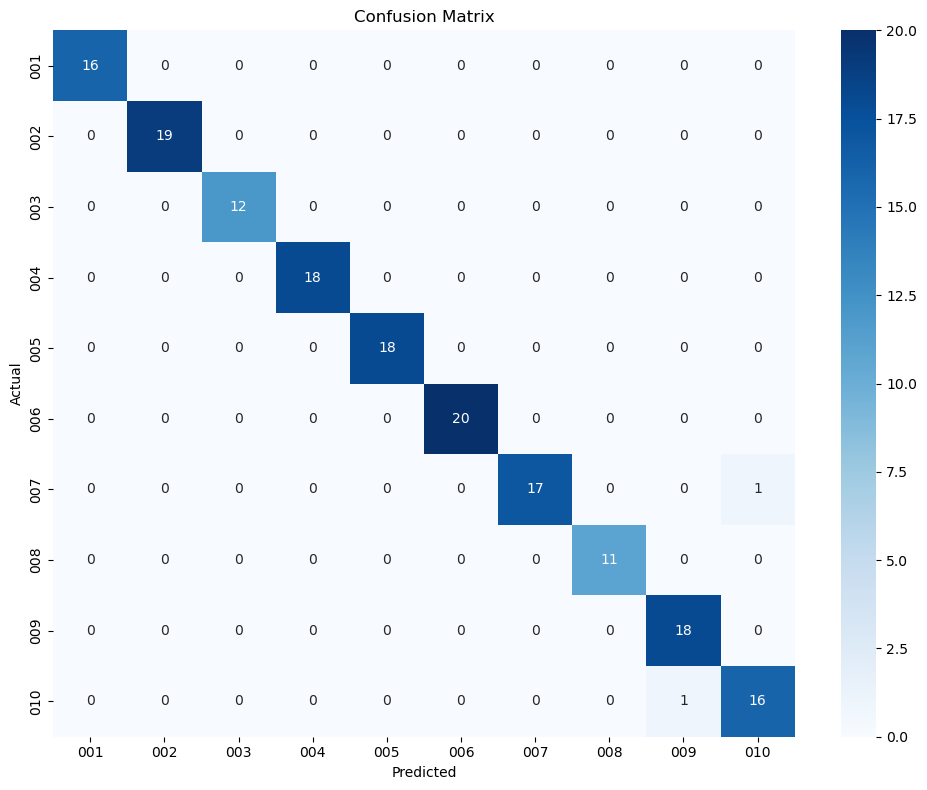

In [12]:
cm = generate_confusion_matrix(
    y_true,
    y_pred
)

plot_confusion_matrix(
    cm,
    sorted(set(labels))
)

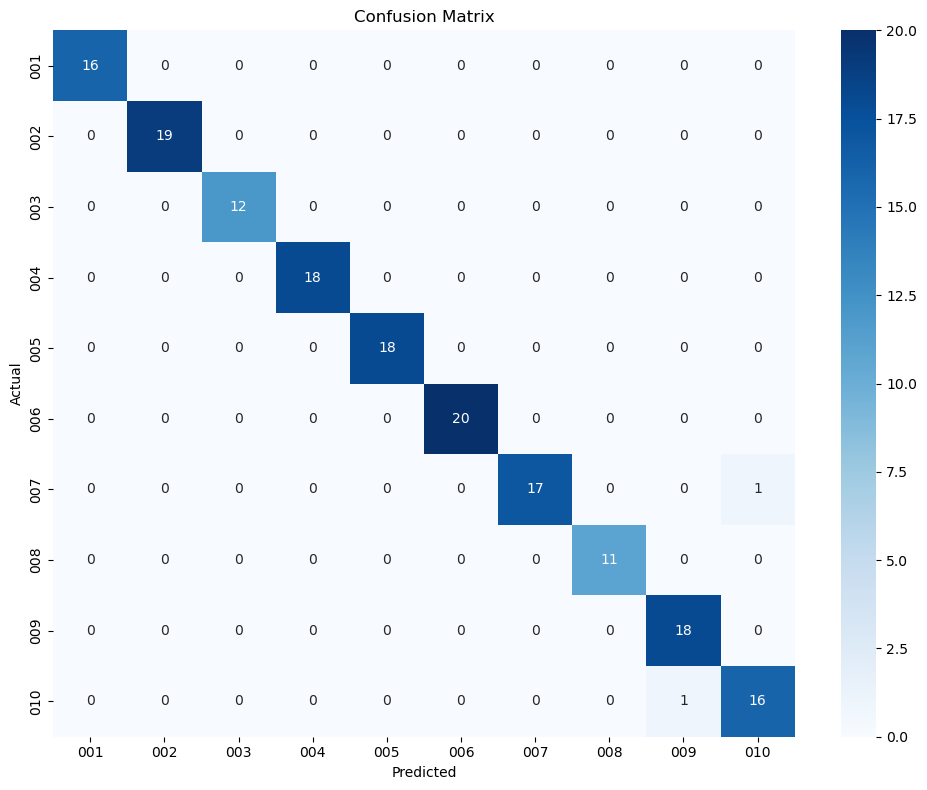

<Figure size 640x480 with 0 Axes>

In [13]:
import matplotlib.pyplot as plt

plot_confusion_matrix(
    cm,
    sorted(set(labels))
)

plt.savefig(
    "../outputs/figures/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)